In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
from IPython.display import display
import matplotlib.patheffects as pe

In [2]:
geo = pd.read_csv('/mnt/scratch/baburish/doublepulse/gnn/Analysis/data/geometry_clean.csv')
X = geo['dom_x']
Y = geo['dom_y']
Z = geo['dom_z']

In [3]:
connection = sqlite3.connect("/mnt/research/IceCube/lownutau/sqlite/virgo_v2/nutau/nutau_virgo_5TeV_lowerbound_skimmed_chunk_022859.002062_0002999_0004.db")
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""
cursor = connection.cursor()
cursor.execute(sql_query)
output = cursor.fetchall()
print(output)

[('CleanedROIPulses',), ('truth',), ('reco',)]


In [4]:
df_truth = pd.read_sql_query("SELECT * FROM truth;", connection)
df_pulses = pd.read_sql_query("SELECT * FROM CleanedROIPulses;", connection)
df_reco = pd.read_sql_query("SELECT * FROM reco;", connection)
connection.close()

In [5]:
print(df_truth.columns)
print(df_pulses.columns)
print(df_reco.columns)

Index(['primary_energy', 'energy', 'position_x', 'position_y', 'position_z',
       'azimuth', 'zenith', 'pid', 'signal', 'sim_type', 'interaction_type',
       'run_id', 'subrun_id', 'event_id', 'subevent_id', 'inelasticity',
       'event_category', 'seed_string', 'tau_prod_vertex_x',
       'tau_prod_vertex_y', 'tau_prod_vertex_z', 'tau_prod_vertex_t',
       'tau_dec_vertex_x', 'tau_dec_vertex_y', 'tau_dec_vertex_z',
       'tau_dec_vertex_t', 'e_prod_vertex_x', 'e_prod_vertex_y',
       'e_prod_vertex_z', 'e_prod_vertex_t', 'mjd', 'TIntProbW', 'OneWeight',
       'Inelasticity_param_a', 'Inelasticity_param_b', 'MCPrimaryType',
       'MCPrimaryAzimuth', 'MCPrimaryEnergy', 'MCPrimaryZenith', 'Event',
       'SubEvent', 'IceScattering', 'IceAbsorption', 'DOMEfficiency',
       'IceAnisotropyScale', 'HoleIceForward_p0', 'HoleIceForward_p1',
       'MuonWeight', 'train_pass', 'event_no'],
      dtype='str')
Index(['charge', 'dom_time', 'dom_x', 'dom_y', 'dom_z', 'event_no'], dtype='st

In [6]:
print(df_truth['interaction_type'].head())
print(df_pulses['dom_time'].head())

0   -1.0
1   -1.0
2   -1.0
3   -1.0
4   -1.0
Name: interaction_type, dtype: float64
0    1313.0
1    1422.0
2    1127.0
3     961.0
4    1292.0
Name: dom_time, dtype: float64


In [7]:
len(df_pulses)
len(df_truth)

292

In [8]:
df_truth.head()

,primary_energy,energy,position_x,position_y,position_z,azimuth,zenith,pid,signal,sim_type,...,SubEvent,IceScattering,IceAbsorption,DOMEfficiency,IceAnisotropyScale,HoleIceForward_p0,HoleIceForward_p1,MuonWeight,train_pass,event_no
0,54363.455668,54363.455668,-636.789105,606.730729,1947.939315,2.355916,0.496703,16.0,1.0,genie,...,0.0,1.051458,0.913186,1.086780,None,0.585234,-0.089036,None,1.0,0
1,16122.232010,16122.232010,-2106.729578,-3673.848435,1946.593105,4.241178,1.026489,-16.0,1.0,genie,...,0.0,1.020073,0.928818,1.089910,None,0.491654,-0.094314,None,1.0,1
2,14050.994683,14050.994683,-4190.120311,-929.720035,1946.554981,3.418685,1.135426,16.0,1.0,genie,...,0.0,1.020073,0.928818,1.089910,None,0.491654,-0.094314,None,1.0,2
3,23649.685192,23649.685192,-2826.901824,2362.730807,1946.935238,2.438609,0.960071,-16.0,1.0,genie,...,0.0,1.004569,1.026774,1.079386,None,0.301758,-0.106165,None,1.0,3
4,29527.090419,29527.090419,327.078707,-23.536847,1947.991565,6.179654,0.090541,16.0,1.0,genie,...,0.0,0.928829,1.077686,0.971851,None,0.574906,-0.037085,None,1.0,4


In [9]:
df_pulses.head()

,charge,dom_time,dom_x,dom_y,dom_z,event_no
0,0.925,1313.0,114.39,-461.99,-267.27,0
1,0.975,1422.0,114.39,-461.99,-284.29,0
2,1.675,1127.0,114.39,-461.99,-301.31,0
3,1.525,961.0,114.39,-461.99,-318.33,0
4,1.025,1292.0,114.39,-461.99,-318.33,0


In [11]:
grouped_piddf = df_truth.groupby('event_no').agg({
    'pid': lambda x: list(x),
}).reset_index()
grouped_piddf.rename(columns={
    'pid': 'pid',
}, inplace=True)

cols_to_convert = ['pid']

for col in cols_to_convert:
    grouped_piddf[col] = grouped_piddf[col].apply(lambda x: np.array(x))

grouped_df = df_pulses.groupby('event_no').agg({
    'charge': lambda x: list(x),
    'dom_x': lambda x: list(x),
    'dom_y': lambda x: list(x),
    'dom_z': lambda x: list(x),
    'dom_time': lambda x: list(x)
}).reset_index()

grouped_df.rename(columns={
    'charge': 'charge',
    'dom_x': 'dom_x',
    'dom_y': 'dom_y',
    'dom_z': 'dom_z',
    'dom_time': 'dom_time'
}, inplace=True)
cols_to_convert = ['charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time']

for col in cols_to_convert:
    grouped_df[col] = grouped_df[col].apply(lambda x: np.array(x))
df = pd.merge(grouped_df, grouped_piddf, on='event_no', how='inner')

print(grouped_df.columns)
print(grouped_piddf.columns)
print(df.columns)
print(len(df['event_no'],))
print(len(df['pid'],))

Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time'], dtype='str')
Index(['event_no', 'pid'], dtype='str')
Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time', 'pid'], dtype='str')
292
292


In [12]:
display(df)

,event_no,charge,dom_x,dom_y,dom_z,dom_time,pid
0,0,"[0.9250000660002753, 0.9749999974167993, 1.674...","[114.39, 114.39, 114.39, 114.39, 114.39, 114.3...","[-461.99, -461.99, -461.99, -461.99, -461.99, ...","[-267.27, -284.29, -301.31, -318.33, -318.33, ...","[1313.0, 1422.0, 1127.0, 961.0, 1292.0, 782.0,...",[16.0]
1,1,"[0.6750000110324312, 0.22499999087634093, 0.57...","[-413.46, -290.66, -290.66, -290.66, -290.66, ...","[-327.27, -307.38, -307.38, -307.38, -307.38, ...","[-453.57, -363.91, -397.96, -432.0, -449.02, -...","[1240.0, 1956.0, 1309.0, 1338.0, 962.0, 1664.0...",[-16.0]
2,2,"[0.6250000004786891, 1.1749999036527767, 1.375...","[-279.53, -279.53, -279.53, -279.53, -279.53, ...","[23.17, 23.17, 23.17, 23.17, 23.17, 23.17, 23....","[77.09, 60.07, 43.05, 26.03, 9.0, 9.0, 9.0, 9....","[698.0, 839.0, 601.0, 878.0, 620.0, 700.0, 750...",[16.0]
3,3,"[0.3749999972969491, 1.0249999674925947, 0.925...","[-403.14, -403.14, -279.53, -279.53, -279.53, ...","[3.49, 3.49, 23.17, 23.17, 23.17, 23.17, 23.17...","[-179.03, -366.25, -263.33, -280.35, -314.39, ...","[1920.0, 1269.0, 1848.0, 1347.0, 1274.0, 1115....",[-16.0]
4,4,"[0.32499999075302344, 0.3749999972969491, 0.32...","[79.41, 79.41, 210.47, 210.47, 210.47, 210.47,...","[-248.24, -248.24, -209.77, -209.77, -209.77, ...","[-352.13, -369.15, -217.93, -268.99, -286.01, ...","[1471.0, 1769.0, 1527.0, 1650.0, 1043.0, 1327....",[16.0]
...,...,...,...,...,...,...,...
287,287,"[0.9250000660002753, 0.9749999974167993, 0.324...","[248.15, 248.15, 248.15, 248.15, 248.15, 371.5...","[-111.87, -111.87, -111.87, -111.87, -111.87, ...","[310.81, 293.79, 276.76, 259.74, 259.74, 383.4...","[1099.0, 995.0, 1205.0, 1156.0, 1747.0, 759.0,...",[-16.0]
288,288,"[1.5249999431937482, 0.774999932675924, 1.0750...","[326.85, 326.85, 326.85, 326.85, 248.15, 248.1...","[-209.07, -209.07, -209.07, -209.07, -111.87, ...","[123.97, 123.97, 123.97, 106.95, 242.72, 225.7...","[305.0, 625.0, 1518.0, 1208.0, 728.0, 779.0, 2...",[16.0]
289,289,"[1.225000063548963, 1.4750000188880557, 0.9749...","[-256.14, -256.14, -256.14, -256.14, -256.14, ...","[-521.08, -521.08, -521.08, -521.08, -521.08, ...","[-167.78, -201.82, -218.84, -252.88, -252.88, ...","[982.0, 849.0, 760.0, 572.0, 1073.0, 791.0, 60...",[16.0]
290,290,"[0.8249999582557979, 0.9250000660002753, 0.725...","[79.41, 210.47, 210.47, 210.47, 210.47, 210.47...","[-248.24, -209.77, -209.77, -209.77, -209.77, ...","[-420.22, -217.93, -234.95, -234.95, -268.99, ...","[1873.0, 1443.0, 1341.0, 1860.0, 1642.0, 1499....",[16.0]


In [13]:
duplicates = df[df.duplicated(subset=['event_no'])]
print(duplicates)

Empty DataFrame
Columns: [event_no, charge, dom_x, dom_y, dom_z, dom_time, pid]
Index: []


In [14]:
print(len(df['event_no'],))
print(len(df['pid'],))

292
292


In [29]:
%matplotlib inline
def flatten_list_column(col):
    flat_list = []
    for item in col:
        if isinstance(item, list):
            flat_list.extend(item)
        else:
            flat_list.append(item)
    return flat_list
# dfrow = df.iloc[10]
dfrow = df.iloc[df['charge'].apply(sum).idxmax()]
print(df['charge'].apply(sum).idxmax())
print(df_truth.iloc[df['charge'].apply(sum).idxmax()])
# print(dfrow['pid'])
dom_x_flat = flatten_list_column(dfrow['dom_x'])
dom_y_flat = flatten_list_column(dfrow['dom_y'])
dom_z_flat = flatten_list_column(dfrow['dom_z'])
charge_flat = flatten_list_column(dfrow['charge'])

df_redpulses = pd.DataFrame({
    'dom_x': dom_x_flat,
    'dom_y': dom_y_flat,
    'dom_z': dom_z_flat,
    'charge': charge_flat,
    'dom_time': flatten_list_column(dfrow['dom_time'])
})



charge_per_dom = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()


229
primary_energy               187750.002178
energy                       187750.002178
position_x                 -1407734.435597
position_y                 -1369459.880117
position_z                  -308157.005549
azimuth                           3.913303
zenith                            1.726242
pid                                   16.0
signal                                 1.0
sim_type                             genie
interaction_type                      -1.0
run_id                        2285902022.0
subrun_id                     4294967295.0
event_id                            3713.0
subevent_id                            0.0
inelasticity                           NaN
event_category                         5.0
seed_string                           44.0
tau_prod_vertex_x              -221.504247
tau_prod_vertex_y                40.220884
tau_prod_vertex_z              -405.822519
tau_prod_vertex_t              -411.672349
tau_dec_vertex_x               -220.133959
tau_dec

53691532
47964143

In [30]:
dom_count = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z']).size().reset_index(name='count')
dom_count = dom_count[dom_count['count'] > 1]
print(dom_count)

      dom_x   dom_y   dom_z  count
2   -403.14    3.49 -451.36      2
3   -403.14    3.49 -434.34      3
5   -403.14    3.49 -400.30      3
6   -403.14    3.49 -366.25      2
7   -403.14    3.49 -349.23      5
..      ...     ...     ...    ...
239   11.87  179.19 -297.63      2
241   46.29  -34.88 -452.19      2
243   46.29  -34.88 -384.10      2
244   46.29  -34.88 -350.06      2
245   46.29  -34.88 -333.04      4

[196 rows x 4 columns]


In [31]:
min(df_redpulses['dom_time']) - min(df_redpulses['dom_time'])

0.0

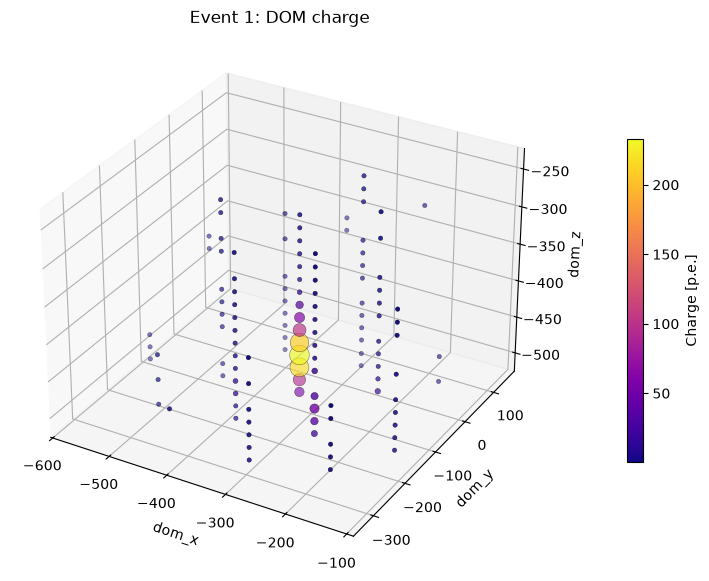

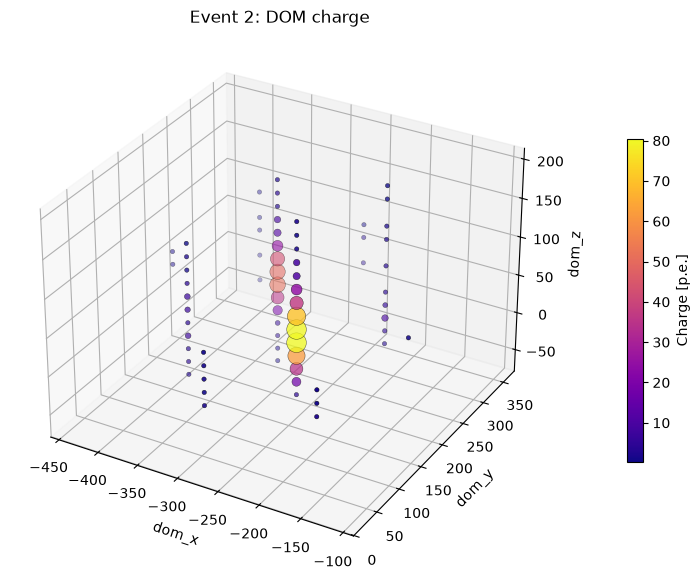

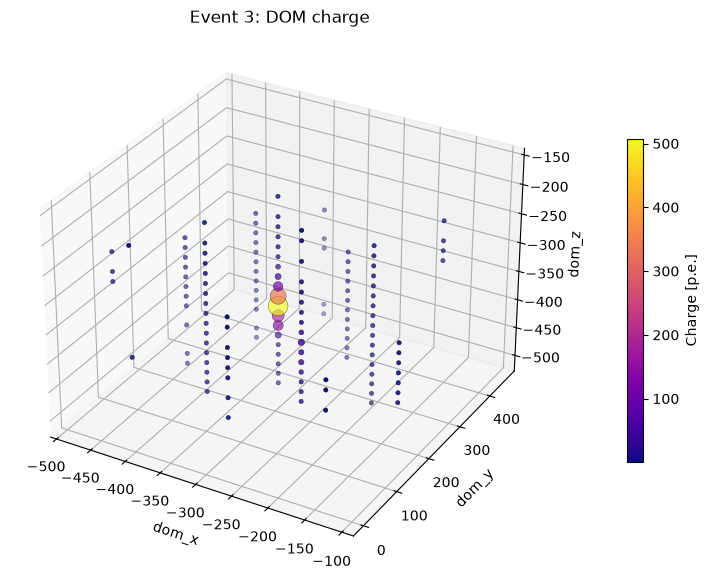

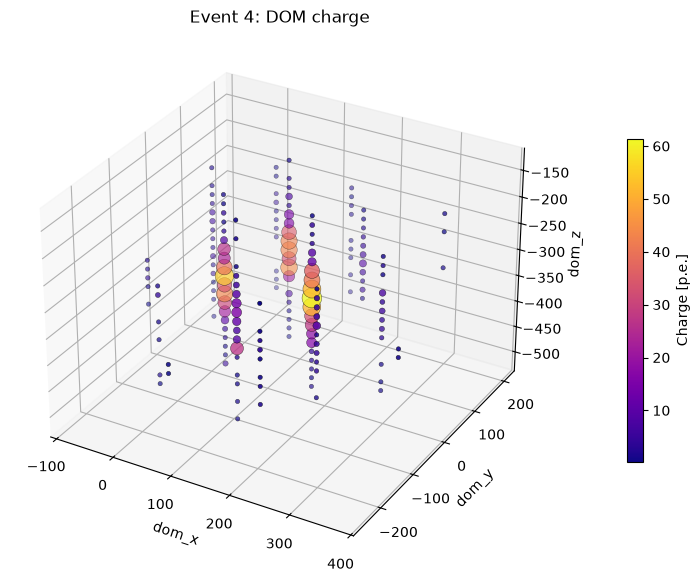

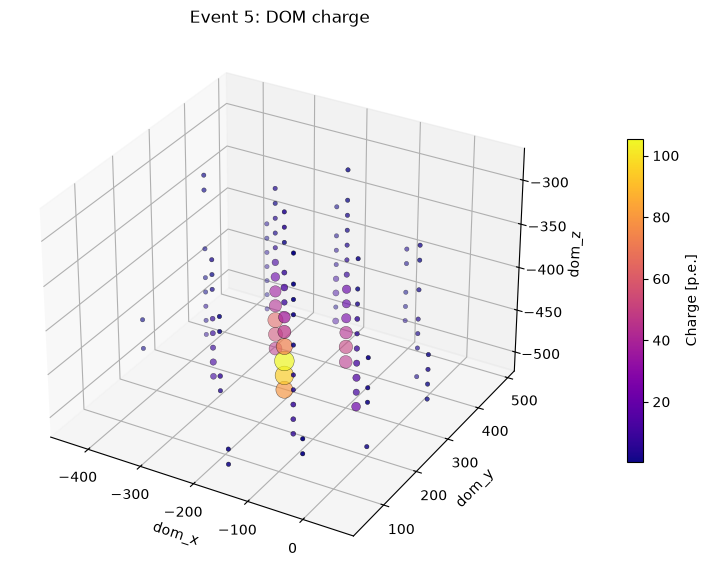

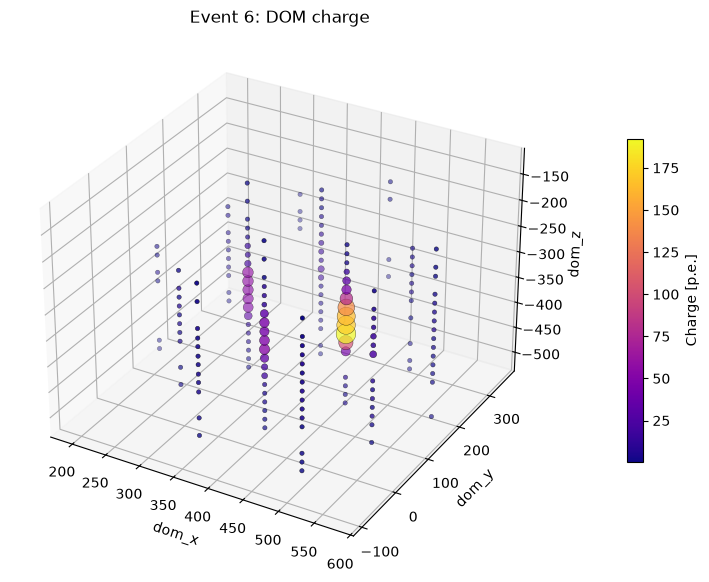

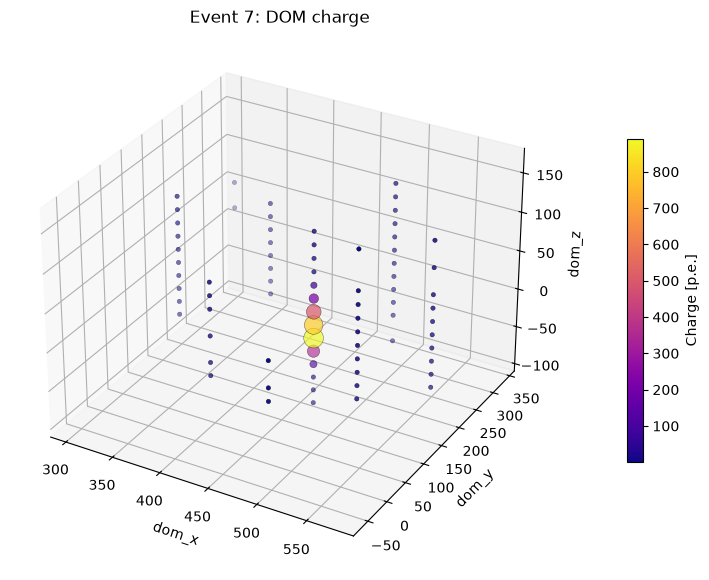

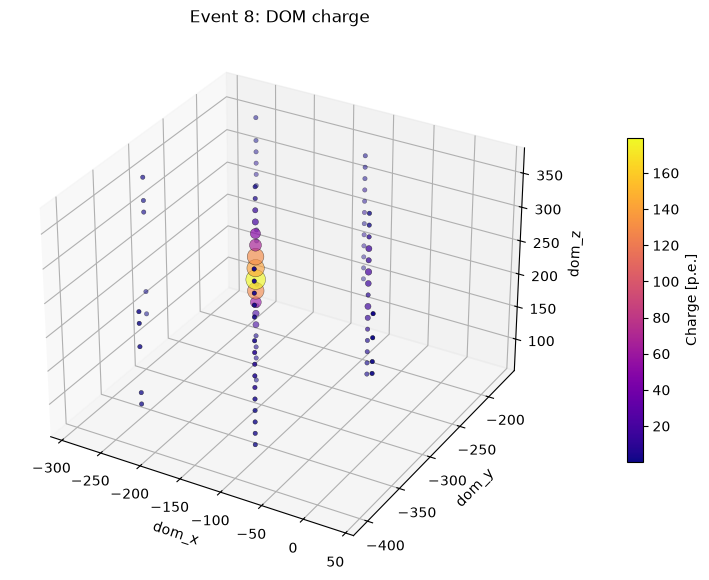

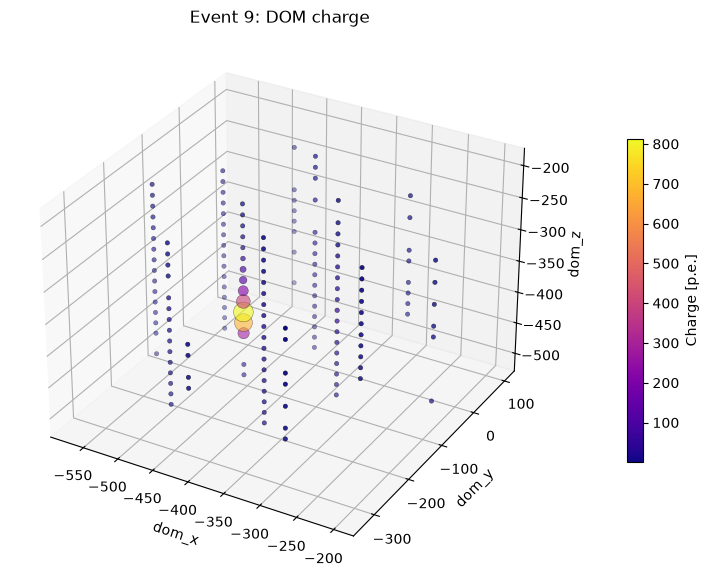

In [37]:
event_no = 3  # set to the event you want
for i in np.arange(1, 10):
    event_no = i
    df_event = df_pulses[df_pulses['event_no'] == event_no]

    charge_per_dom = df_event.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()
    x, y, z, charge = charge_per_dom['dom_x'], charge_per_dom['dom_y'], charge_per_dom['dom_z'], charge_per_dom['charge']

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    im = ax.scatter(x, y, z, c=charge, s=np.clip(charge / charge.max() * 200, 10, 200),
                    cmap='plasma', edgecolors='k', linewidths=0.3, zorder=100)
    ax.set_xlabel('dom_x')
    ax.set_ylabel('dom_y')
    ax.set_zlabel('dom_z')
    ax.set_title(f'Event {event_no}: DOM charge')

    cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label('Charge [p.e.]')

    plt.show()

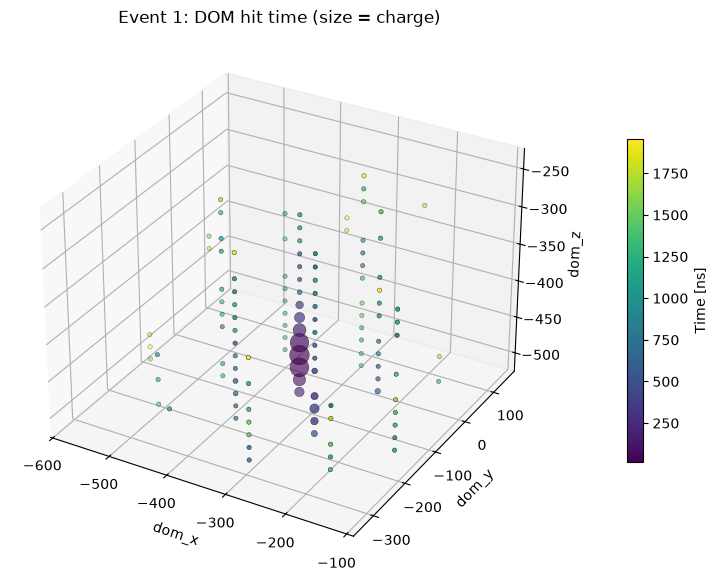

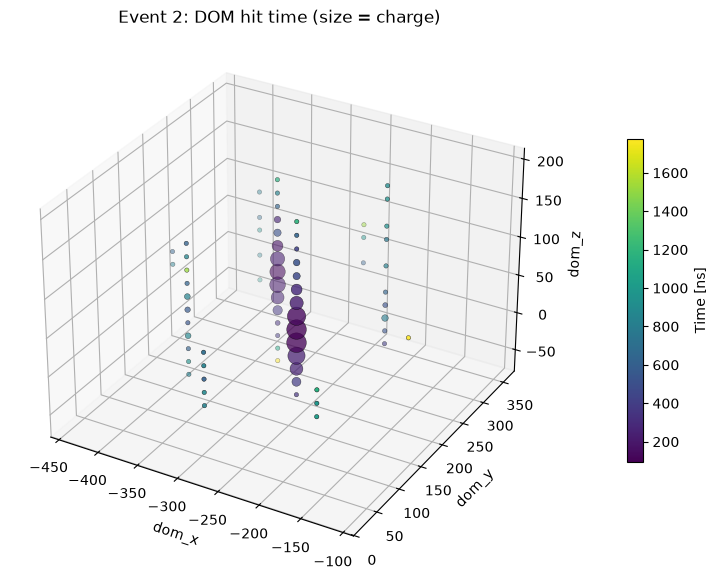

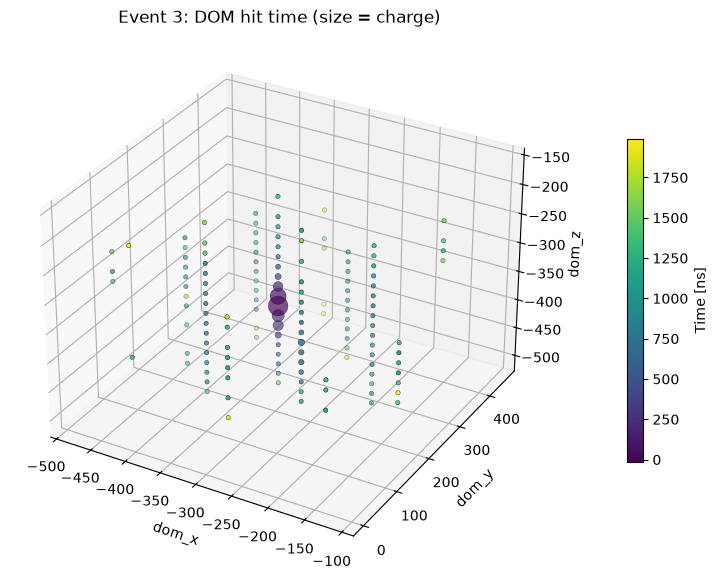

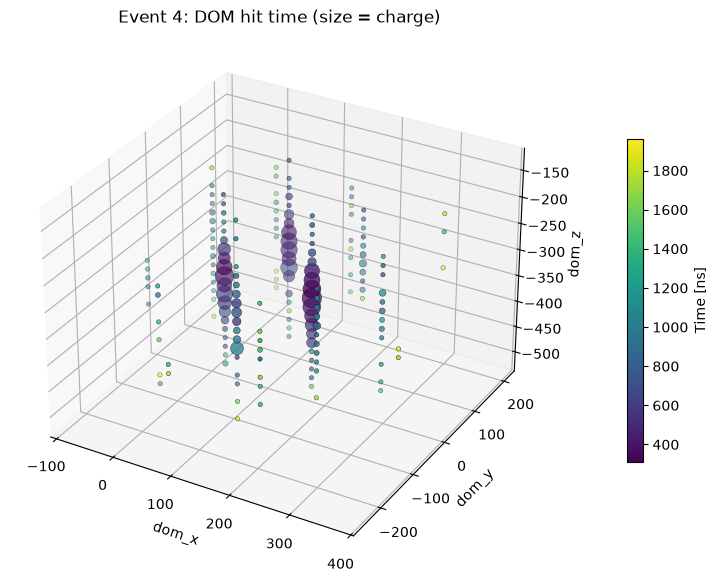

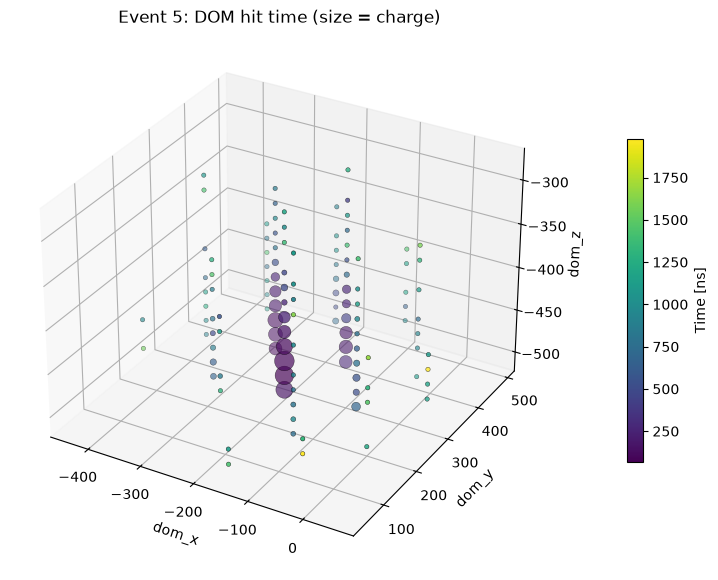

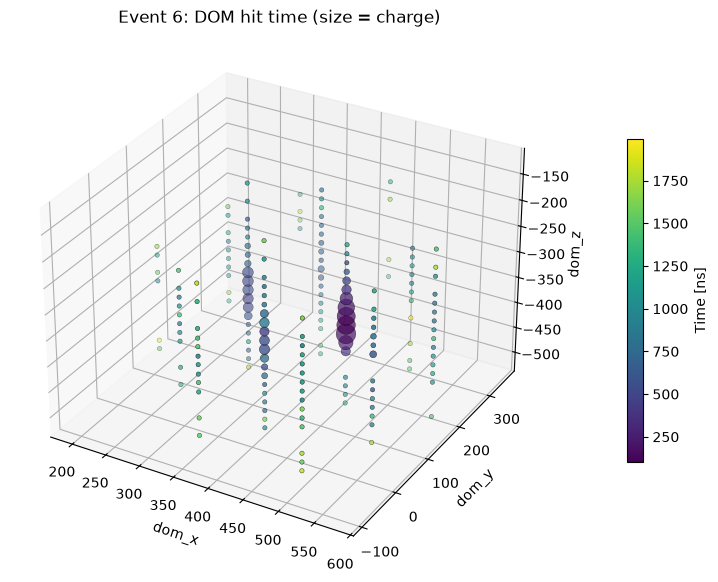

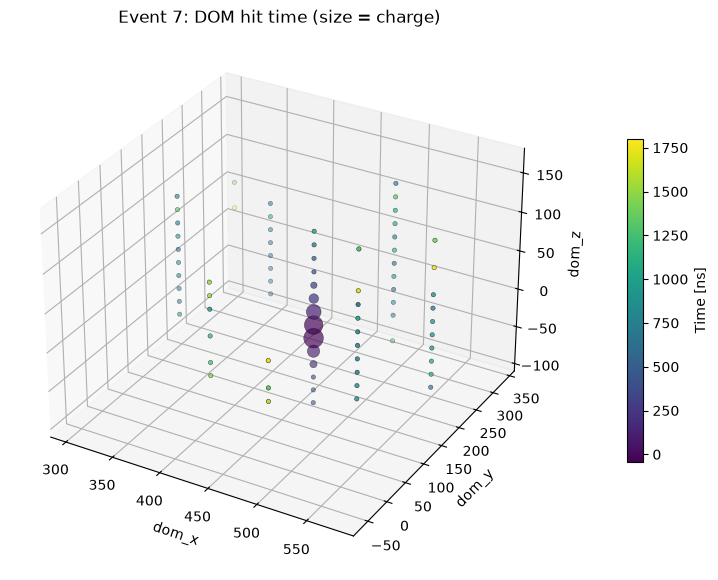

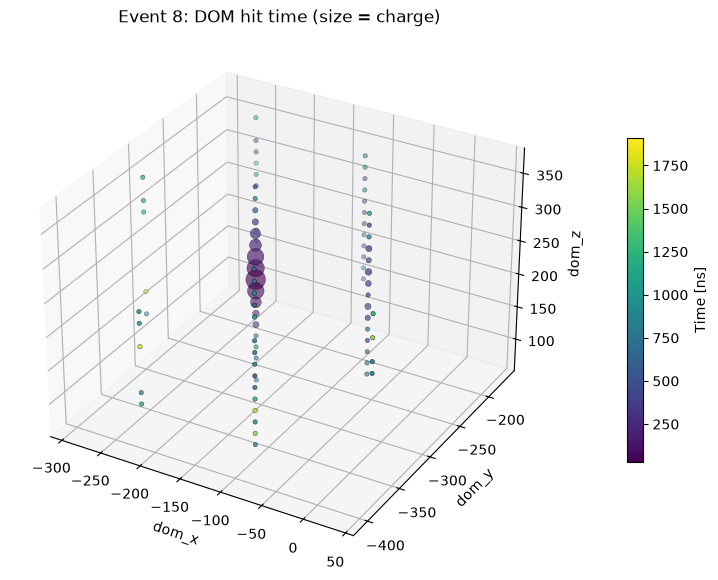

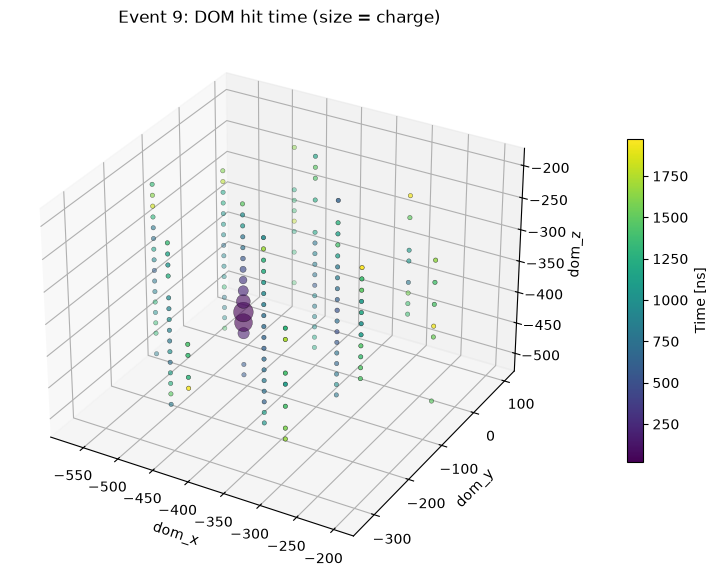

In [39]:
event_no = 1  # set to the event you want

for i in np.arange(1, 10):
    event_no = i
    df_event = df_pulses[df_pulses['event_no'] == event_no]

    dom_stats = df_event.groupby(['dom_x', 'dom_y', 'dom_z']).apply(
        lambda g: pd.Series({
            'charge': g['charge'].sum(),
            't_mean': np.average(g['dom_time'], weights=g['charge']),  # charge-weighted mean hit time
        })
    ).reset_index()

    x, y, z = dom_stats['dom_x'], dom_stats['dom_y'], dom_stats['dom_z']
    charge, t_mean = dom_stats['charge'], dom_stats['t_mean']

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    im = ax.scatter(x, y, z, c=t_mean, s=np.clip(charge / charge.max() * 200, 10, 200),
                    cmap='viridis', edgecolors='k', linewidths=0.3, zorder=100)
    ax.set_xlabel('dom_x')
    ax.set_ylabel('dom_y')
    ax.set_zlabel('dom_z')
    ax.set_title(f'Event {event_no}: DOM hit time (size = charge)')

    cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label('Time [ns]')

    plt.show()

In [19]:
# Strings are identified by DOMs sharing the same (dom_x, dom_y); dom_z varies along a string.
charge_per_string = (df_redpulses
                      .groupby(['dom_x', 'dom_y'])['charge']
                      .sum()
                      .sort_values(ascending=False))

brightest_x, brightest_y = charge_per_string.index[0]
brightest_total_charge = charge_per_string.iloc[0]

string_pulses = (df_redpulses[(df_redpulses['dom_x'] == brightest_x) &
                               (df_redpulses['dom_y'] == brightest_y)]
                  .sort_values('dom_time')
                  .reset_index(drop=True))

print(f"event_no = {dfrow['event_no']}")
print(f"n_strings_hit = {len(charge_per_string)}")
print(f"brightest string: dom_x={brightest_x}, dom_y={brightest_y}, "
      f"total charge = {brightest_total_charge:.2f} p.e., "
      f"n_doms_on_string = {string_pulses['dom_z'].nunique()}, "
      f"n_pulses_on_string = {len(string_pulses)}")

string_pulses

event_no = 229
n_strings_hit = 19
brightest string: dom_x=-156.23, dom_y=43.37, total charge = 3117.95 p.e., n_doms_on_string = 18, n_pulses_on_string = 770


,dom_x,dom_y,dom_z,charge,dom_time
0,-156.23,43.37,-401.26,3.975000,-115.0
1,-156.23,43.37,-401.26,3.975000,-113.0
2,-156.23,43.37,-401.26,8.725000,-110.0
3,-156.23,43.37,-401.26,21.074999,-108.0
4,-156.23,43.37,-401.26,17.475002,-105.0
...,...,...,...,...,...
765,-156.23,43.37,-367.22,1.075000,1902.0
766,-156.23,43.37,-469.35,0.575000,1928.0
767,-156.23,43.37,-384.24,0.975000,1932.0
768,-156.23,43.37,-367.22,1.625000,1946.0


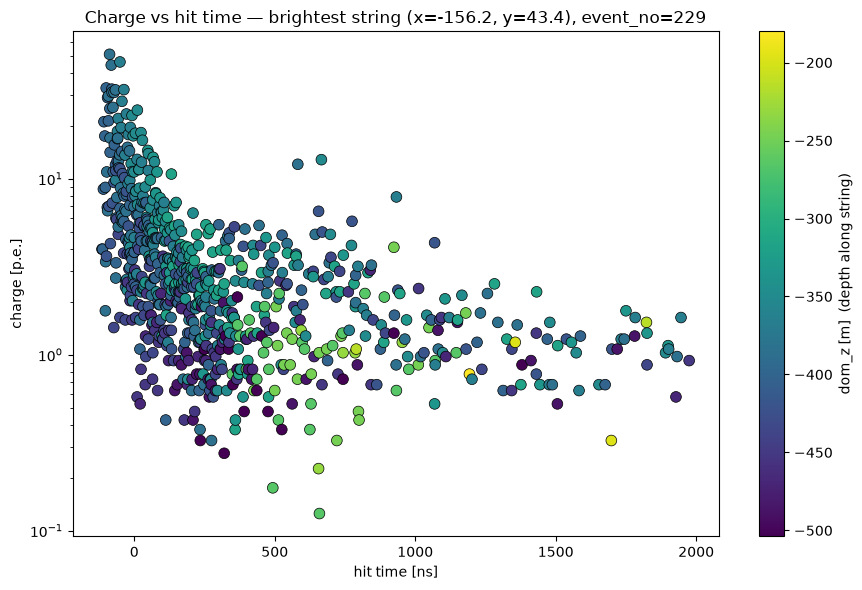

In [20]:
import matplotlib.colors as colors
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(string_pulses['dom_time'], string_pulses['charge'],
                 c=string_pulses['dom_z'], cmap='viridis', #norm=colors.LogNorm(),
                 s=60, edgecolors='k', linewidths=0.5)
ax.set_xlabel('hit time [ns]')
ax.set_ylabel('charge [p.e.]')
ax.set_yscale('log')
ax.set_title(f"Charge vs hit time — brightest string "
             f"(x={brightest_x:.1f}, y={brightest_y:.1f}), event_no={dfrow['event_no']}")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('dom_z [m]  (depth along string)')
plt.tight_layout()
plt.show()

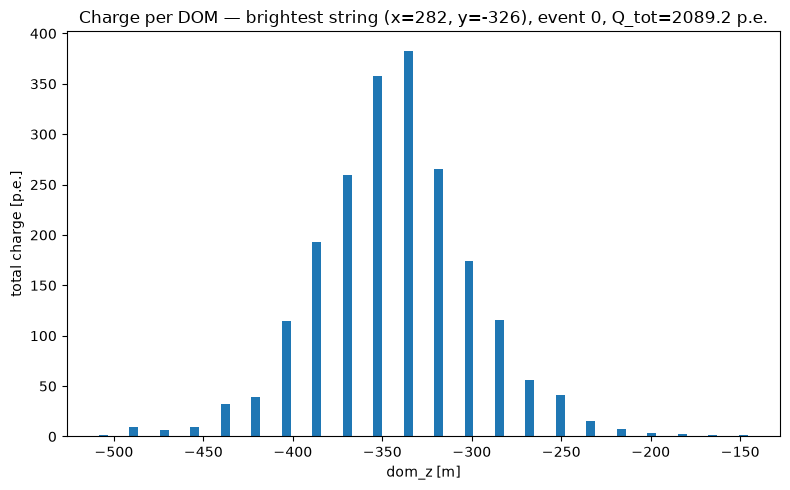

In [21]:
def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

event_no = df['event_no'].iloc[0]  # <- set the event to analyze

string_pulses, bx, by, total_q = brightest_string_pulses(event_no)

charge_per_dom_on_string = (string_pulses
                             .groupby('dom_z')['charge']
                             .sum()
                             .sort_index())

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(charge_per_dom_on_string.index, charge_per_dom_on_string.values, width=5)
ax.set_xlabel('dom_z [m]')
ax.set_ylabel('total charge [p.e.]')
ax.set_title(f'Charge per DOM — brightest string (x={bx:.0f}, y={by:.0f}), event {event_no}, Q_tot={total_q:.1f} p.e.')
plt.tight_layout()
plt.show()

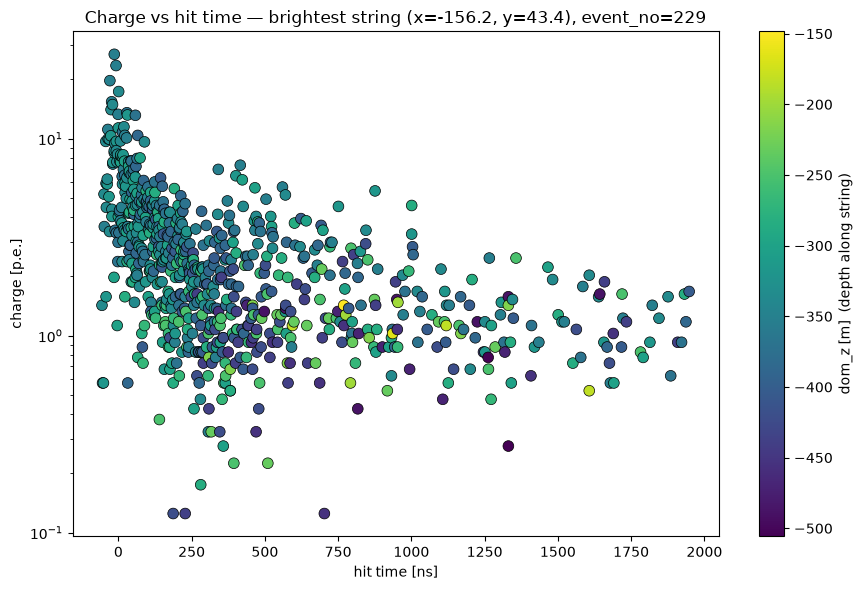

In [22]:
import matplotlib.colors as colors
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(string_pulses['dom_time'], string_pulses['charge'],
                 c=string_pulses['dom_z'], cmap='viridis',# norm=colors.LogNorm(),
                 s=60, edgecolors='k', linewidths=0.5)
ax.set_xlabel('hit time [ns]')
ax.set_ylabel('charge [p.e.]')
ax.set_yscale('log')
ax.set_title(f"Charge vs hit time — brightest string "
             f"(x={brightest_x:.1f}, y={brightest_y:.1f}), event_no={dfrow['event_no']}")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('dom_z [m]  (depth along string)')
plt.tight_layout()
plt.show()

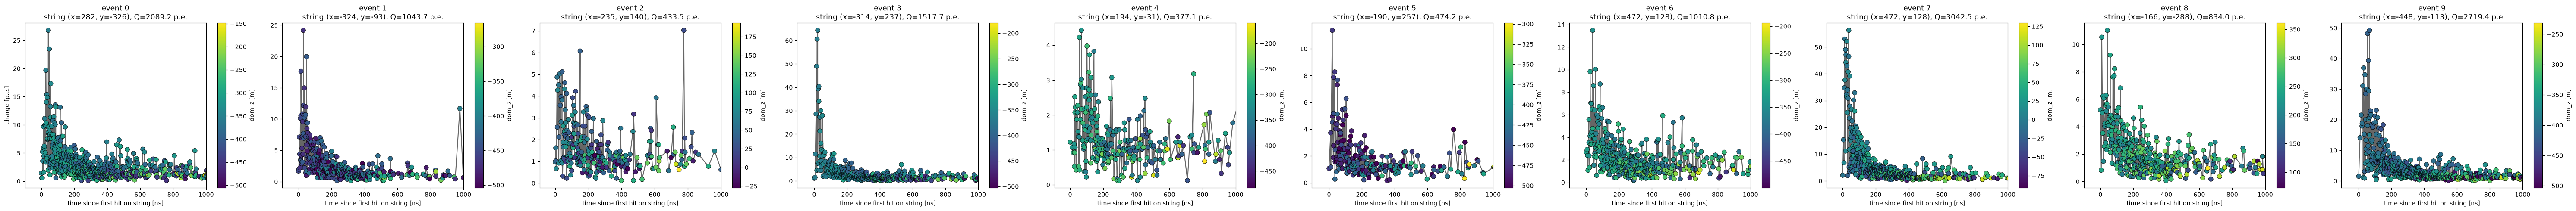

In [23]:
n_events = 10
charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

event_list = df['event_no'].iloc[:n_events].tolist()

def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    # ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')
    ax.set_xlim(right=1000)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()

selected 8 events with brightest-string charge > 0 p.e.: [0, 1, 2, 3, 4, 5, 6, 7]


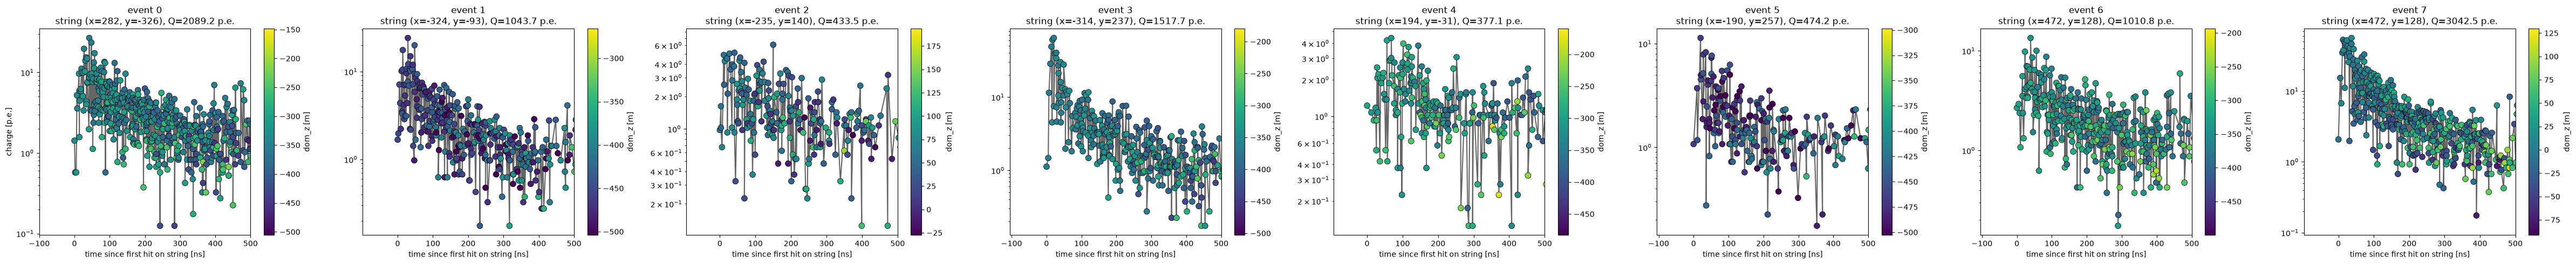

In [24]:
def brightest_string_pulses(event_no):
    dfrow = df[df['event_no'] == event_no].iloc[0]
    ev_pulses = pd.DataFrame({
        'dom_x': dfrow['dom_x'], 'dom_y': dfrow['dom_y'], 'dom_z': dfrow['dom_z'],
        'charge': dfrow['charge'], 'dom_time': dfrow['dom_time'],
    })
    charge_per_string = ev_pulses.groupby(['dom_x', 'dom_y'])['charge'].sum().sort_values(ascending=False)
    bx, by = charge_per_string.index[0]
    string_pulses = (ev_pulses[(ev_pulses['dom_x'] == bx) & (ev_pulses['dom_y'] == by)]
                      .sort_values('dom_time')
                      .reset_index(drop=True))
    return string_pulses, bx, by, charge_per_string.iloc[0]

n_events = 8
charge_threshold_event = 0

event_list = []
for ev in df['event_no']:
    _, _, _, total_q = brightest_string_pulses(ev)
    if total_q > charge_threshold_event:
        event_list.append(ev)
    if len(event_list) == n_events:
        break

print(f"selected {len(event_list)} events with brightest-string charge > {charge_threshold_event} p.e.: {event_list}")

charge_threshold = 0  # p.e. — drop any dom_z with a hit below this

n = len(event_list)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)
if n == 1:
    axes = [axes]

for ax, ev in zip(axes, event_list):
    string_pulses, bx, by, total_q = brightest_string_pulses(ev)

    min_charge_per_dom = string_pulses.groupby('dom_z')['charge'].min()
    keep_doms = min_charge_per_dom[min_charge_per_dom >= charge_threshold].index
    string_pulses = string_pulses[string_pulses['dom_z'].isin(keep_doms)].reset_index(drop=True)

    shifted = string_pulses.copy()
    shifted['dom_time'] = string_pulses['dom_time'] - string_pulses['dom_time'].min()

    ax.plot(shifted['dom_time'], shifted['charge'], '-o', color='0.4', zorder=1)
    sc = ax.scatter(shifted['dom_time'], shifted['charge'],
                     c=string_pulses['dom_z'], cmap='viridis',
                     s=60, edgecolors='k', linewidths=0.5, zorder=2)
    ax.set_xlabel('time since first hit on string [ns]')
    ax.set_yscale('log')
    ax.set_title(f"event {ev}\nstring (x={bx:.0f}, y={by:.0f}), Q={total_q:.1f} p.e.")
    fig.colorbar(sc, ax=ax, label='dom_z [m]')
    ax.set_xlim(right=500)

axes[0].set_ylabel('charge [p.e.]')
plt.tight_layout()
plt.show()